<a href="https://colab.research.google.com/github/Valrite/Digital-Image-Processing-Labs/blob/main/Lab7/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Program 7
# Write a Program to read an image. Extract and display low-level features,
# texture features and color features.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern, hog
from skimage import exposure


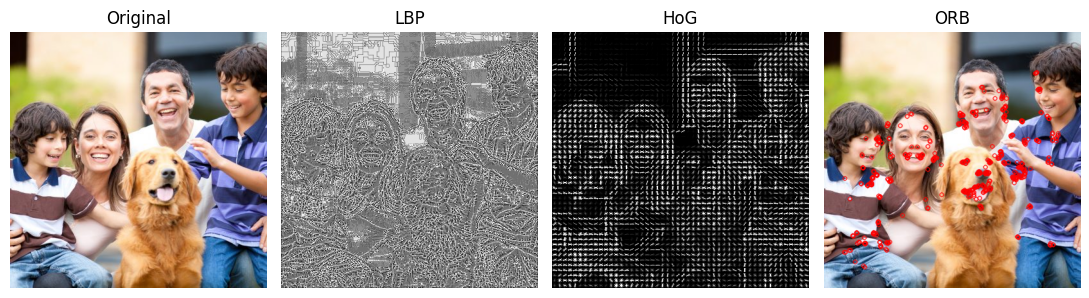

In [5]:
#read image
img1 = cv2.imread("pet.jpg")

#create an rgb image and a gray image
image_rgb1 = cv2.cvtColor(img1,cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)

# Local Binary Pattern (LBP)
lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')

# Histogram of Oriented Gradients (HOG)
hog_features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True,
    block_norm='L2-Hys'
)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0,10))

# ORB Keypoints
orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(gray, None)
orb_image = cv2.drawKeypoints(image_rgb1, keypoints, None, color=(255,0,0))

# plot images
fig, axes = plt.subplots(1, 4, figsize=(11, 4))
titles = ["Original", "LBP", "HoG","ORB"]
images = [image_rgb1,lbp ,hog_image_rescaled,orb_image]
for i in range(4):
      axes[i].imshow(images[i], cmap='gray')
      axes[i].set_title(titles[i])
      axes[i].axis("off")
plt.tight_layout()
plt.show()

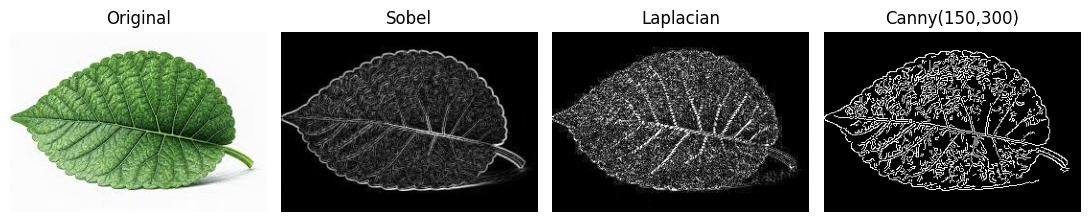

In [4]:
#read image
img2 = cv2.imread("leaf.jpeg")

#create rgb image and gray image
image_rgb = cv2.cvtColor(img2,cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

# apply sobel filters on the gray image
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

# apply laplacian filter on the image
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian_abs = cv2.convertScaleAbs(laplacian)

#apply canny edge detection on image
canny = cv2.Canny(gray, 150, 300)

#plot the images
fig, axes = plt.subplots(1, 4, figsize=(11, 4))
titles = ["Original", "Sobel", "Laplacian","Canny(150,300)"]
images = [image_rgb,sobel_combined ,laplacian_abs,canny]
for i in range(4):
      axes[i].imshow(images[i], cmap='gray')
      axes[i].set_title(titles[i])
      axes[i].axis("off")
plt.tight_layout()
plt.show()

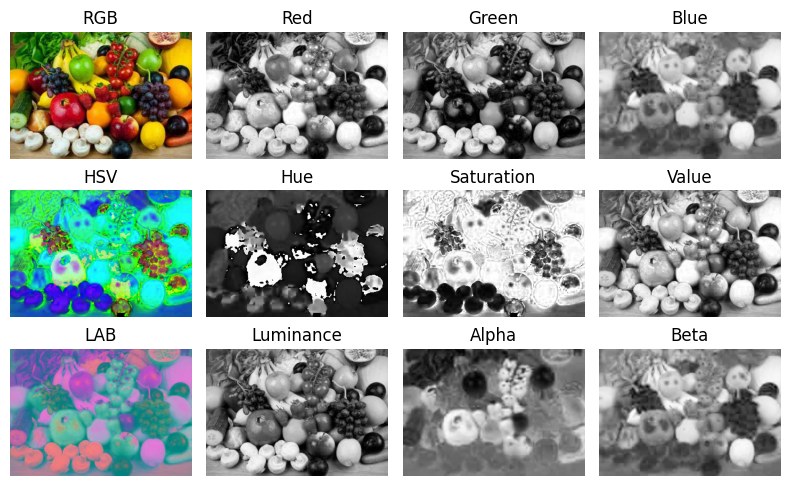

In [ ]:
#read image


im = cv2.imread("images/fruits2.jpeg")

#convert image to RGB, HSV and LAB color spaces
rgb = cv2.cvtColor(im,cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(im,cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(im,cv2.COLOR_BGR2LAB)

# Split channels
r, g, b = cv2.split(rgb)
h, s, v = cv2.split(hsv)
l, a, b = cv2.split(lab)

#display images
fig, axes = plt.subplots(3,4, figsize=(8, 5))
titles = ["RGB", "Red", "Green","Blue", "HSV","Hue","Saturation","Value","LAB","Luminance","Alpha","Beta"]
images = [rgb,r,g,b,hsv,h,s,v,lab,l,a,b]
axes=axes.flatten()
for i in range(12):
    axes[i].imshow(images[i],cmap="grey")
    axes[i].set_title(titles[i])
    axes[i].axis("off")
plt.tight_layout()
plt.show()


<h2>Texture Feature Extraction from Images</h2>

<p>
Texture features help describe the <b>surface characteristics and patterns</b> present in an image.
They are useful in many computer vision tasks such as object recognition, face detection,
medical image analysis, and image classification.
</p>

<p>
Some commonly used texture feature extraction methods are:
</p>

<ul>
<li><b>LBP (Local Binary Pattern)</b></li>
<li><b>HOG (Histogram of Oriented Gradients)</b></li>
<li><b>ORB (Oriented FAST and Rotated BRIEF)</b></li>
</ul>

<hr>

<h3>1. Local Binary Pattern (LBP)</h3>

<p>
LBP is a simple and efficient texture descriptor. It works by comparing the intensity
of each pixel with its neighboring pixels. If the neighbor pixel value is greater
than or equal to the center pixel, it is assigned a value of <b>1</b>, otherwise <b>0</b>.
The binary pattern formed is converted into a decimal number which represents the
texture at that location.
</p>

<p><b>Syntax:</b></p>

<pre>
lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
</pre>

<p><b>Explanation:</b></p>
<ul>
<li><b>gray</b> – grayscale input image</li>
<li><b>P=8</b> – number of neighboring pixels</li>
<li><b>R=1</b> – radius of the circular neighborhood</li>
<li><b>method='uniform'</b> – uniform LBP pattern used for better texture representation</li>
</ul>

<hr>

<h3>2. Histogram of Oriented Gradients (HOG)</h3>

<p>
HOG (Histogram of Oriented Gradients) is a feature descriptor used in computer vision to help computers recognize objects such as people, vehicles, or animals in images. Instead of looking at raw pixel values, HOG looks at the shape and structure of objects by analyzing edges and gradients in the image.
</p>
HOG represents an image by describing how edges are oriented in different parts of the image.


<p><b>Syntax:</b></p>

<pre>
hog_features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True,
    block_norm='L2-Hys'
)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0,10))
</pre>

<p><b>Explanation:</b></p>

<ul>
<li><b>gray</b> – grayscale input image</li>
<li><b>orientations=9</b> – number of gradient direction bins</li>
<li><b>pixels_per_cell=(8,8)</b> – size of each cell</li>
<li><b>cells_per_block=(2,2)</b> – number of cells used for normalization</li>
<li><b>visualize=True</b> – generates an image showing gradient patterns</li>
<li><b>block_norm='L2-Hys'</b> – normalization method used for stable feature values</li>
</ul>

<p>
The <b>rescale_intensity()</b> function improves the visibility of the HOG image
so that gradient patterns can be clearly visualized.
</p>

<hr>

<h3>3. ORB (Oriented FAST and Rotated BRIEF)</h3>

<p>
ORB is a fast and efficient feature detector and descriptor. It detects
<b>keypoints (important interest points)</b> such as corners and edges in the image.
ORB is commonly used for feature matching, object detection and image stitching.
</p>

<p><b>Syntax:</b></p>

<pre>
orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(gray, None)
orb_image = cv2.drawKeypoints(image_rgb, keypoints, None, color=(255,0,0))
</pre>

<p><b>Explanation:</b></p>

<ul>
<li><b>cv2.ORB_create()</b> – creates an ORB feature detector</li>
<li><b>detectAndCompute()</b> – detects keypoints and computes feature descriptors</li>
<li><b>keypoints</b> – important feature locations detected in the image</li>
<li><b>descriptors</b> – numerical feature vectors describing each keypoint</li>
<li><b>drawKeypoints()</b> – draws detected keypoints on the image for visualization</li>
</ul>

<hr>


<h2>Low-Level Feature Extraction: Edge Detection</h2>

<p>
Low-level features represent the basic structural information present in an image.
One of the most important low-level features is <b>edges</b>. Edges correspond to
locations where there is a sudden change in intensity or brightness.
</p>

<p>
Edge detection is widely used in computer vision for:
</p>

<ul>
<li>Object detection</li>
<li>Image segmentation</li>
<li>Feature extraction</li>
<li>Shape analysis</li>
</ul>

<p>
Some commonly used edge detection techniques are:
</p>

<ul>
<li><b>Sobel Edge Detection</b></li>
<li><b>Laplacian Edge Detection</b></li>
<li><b>Canny Edge Detection</b></li>
</ul>

<hr>

<h3>1. Sobel Edge Detection</h3>

<p>
The Sobel operator detects edges by calculating the <b>gradient of image intensity</b>.
It measures how rapidly pixel values change in horizontal and vertical directions.
</p>

<p>
Two Sobel filters are commonly used:
</p>

<ul>
<li><b>Sobel X</b> – detects horizontal intensity changes (vertical edges)</li>
<li><b>Sobel Y</b> – detects vertical intensity changes (horizontal edges)</li>
</ul>

<p><b>Syntax:</b></p>

<pre>
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)
</pre>

<p><b>Explanation:</b></p>

<ul>
<li><b>gray</b> – grayscale input image</li>
<li><b>cv2.CV_64F</b> – output image depth (64-bit float for accurate gradient values)</li>
<li><b>1, 0</b> – derivative taken in x-direction</li>
<li><b>0, 1</b> – derivative taken in y-direction</li>
<li><b>ksize=3</b> – size of the Sobel kernel</li>
<li><b>cv2.magnitude()</b> – combines horizontal and vertical gradients to produce the overall edge magnitude</li>
</ul>

<hr>

<h3>2. Laplacian Edge Detection</h3>

<p>
The Laplacian operator detects edges by calculating the <b>second derivative</b>
of the image. It highlights regions where the intensity changes rapidly.
</p>

<p>
Unlike Sobel, Laplacian detects edges in <b>all directions simultaneously</b>.
</p>

<p><b>Syntax:</b></p>

<pre>
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian_abs = cv2.convertScaleAbs(laplacian)
</pre>

<p><b>Explanation:</b></p>

<ul>
<li><b>gray</b> – grayscale input image</li>
<li><b>cv2.CV_64F</b> – output image depth for accurate edge values</li>
<li><b>cv2.convertScaleAbs()</b> – converts the result to an absolute 8-bit image for proper visualization</li>
</ul>

<p>
Laplacian is very sensitive to noise, so it is often used after applying smoothing
or Gaussian filtering.
</p>

<hr>

<h3>3. Canny Edge Detection</h3>

<p>
Canny edge detection is a multi-stage algorithm that provides more accurate
and reliable edge detection compared to simple gradient methods.
</p>

<p>
The Canny algorithm performs the following steps:
</p>

<ol>
<li>Noise reduction using Gaussian filtering</li>
<li>Gradient calculation</li>
<li>Non-maximum suppression to thin edges</li>
<li>Double thresholding to identify strong and weak edges</li>
<li>Edge tracking by hysteresis</li>
</ol>

<p><b>Syntax:</b></p>

<pre>
canny = cv2.Canny(gray, 100, 200)
</pre>

<p><b>Explanation:</b></p>

<ul>
<li><b>gray</b> – grayscale input image</li>
<li><b>100</b> – lower threshold value</li>
<li><b>200</b> – upper threshold value</li>
</ul>

<p>
Pixels with gradient values above the upper threshold are considered strong edges,
while pixels between the thresholds are considered weak edges and are included
only if they are connected to strong edges.
</p>

<hr>


<h2>Color Spaces in Image Processing</h2>

<p>
Color is an important feature in images and can be used for object detection,
segmentation and classification. A <b>color space</b> is a way of representing
colors using numerical values. Different color spaces represent color
information in different ways, which makes them useful for different
applications in computer vision.
</p>

<p>
Some commonly used color spaces are:
</p>

<ul>
<li><b>RGB (Red, Green, Blue)</b></li>
<li><b>HSV (Hue, Saturation, Value)</b></li>
<li><b>LAB (Lightness, A, B)</b></li>
</ul>

<hr>
<hr>

<h3>1. RGB Color Space</h3>

<p>
RGB is the most common color space used in digital images. It represents
colors as a combination of three primary color components:
<b>Red, Green and Blue</b>.
</p>

<p>
Each pixel in an RGB image contains three values that indicate the intensity
of red, green and blue. By combining these values in different proportions,
a wide range of colors can be produced.
</p>

<hr>

<h3>2. HSV Color Space</h3>

<p>
HSV represents colors using three components:
</p>

<ul>
<li><b>Hue (H)</b> – represents the type of color</li>
<li><b>Saturation (S)</b> – represents the purity or intensity of the color</li>
<li><b>Value (V)</b> – represents the brightness of the color</li>
</ul>

<p>
HSV separates color information from brightness, making it useful for
color detection and segmentation tasks.
</p>

<hr>

<h3>3. LAB Color Space</h3>

<p>
LAB is a color space designed to represent colors in a way that is closer
to human visual perception. It separates brightness from color information.
</p>

<p>
LAB consists of three components:
</p>

<ul>
<li><b>L</b> – Lightness (brightness)</li>
<li><b>A</b> – color component from green to red</li>
<li><b>B</b> – color component from blue to yellow</li>
</ul>


<hr>
